# Word-count threshold ablation for MMLU-PT

**Research question.** How do minimum and maximum question-length thresholds affect dataset retention and representation across exams and academic levels?

This notebook is a reproducible, distributional ablation designed to inform the `min_words` and `max_words` parameters of NeMo Curator's `WordCountFilter`. The study uses the dataset materialized immediately after structural MCQA validation and immediately before word-count filtering.

## Abstract

Length filtering can remove malformed fragments, but aggressive thresholds may discard valid short prompts or long passage-based questions and may disproportionately affect individual sources. We quantify these trade-offs through independent and joint threshold sweeps, subgroup retention analysis, and deterministic qualitative inspection of boundary cases. This is a coverage and sensitivity study: without semantic quality labels or downstream model evaluation, length alone cannot establish causal improvements in benchmark quality.

In [1]:
from __future__ import annotations

import hashlib
import platform
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from nemo_curator.stages.text.filters.heuristic import WordCountFilter

SEED = 42
MIN_THRESHOLDS = [0, 1, 2, 3, 4, 5, 8, 10, 15, 20, 30, 50]
MAX_THRESHOLDS = [100, 200, 300, 500, 750, 1_000, 1_500, 2_000, 3_000, 1_000_000]
NEUTRAL_MIN = 0
NEUTRAL_MAX = 1_000_000

sns.set_theme(context="paper", style="whitegrid", font_scale=1.1)
pd.set_option("display.max_colwidth", 180)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

def find_repo_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "pyproject.toml").is_file():
            return candidate
    raise FileNotFoundError("Could not locate the repository root from the current directory.")

REPO_ROOT = find_repo_root(Path.cwd())
INPUT_DIR = REPO_ROOT / "output" / "03 - pre-word-filter"
print(f"Repository: {REPO_ROOT}")
print(f"Input: {INPUT_DIR}")
print(f"Python: {platform.python_version()}")

Repository: /home/aluno_paulosantana/workspace/repositories/mmlu-pt
Input: /home/aluno_paulosantana/workspace/repositories/mmlu-pt/output/03 - pre-word-filter
Python: 3.12.3


## 1. Data and reproducibility

The input is the public-field projection produced after alternative, choice-count, and answer validation. Files are sorted before loading and hashing. The SHA-256 fingerprint identifies the exact materialized snapshot analyzed below.

In [2]:
EXPECTED_COLUMNS = [
    "exam",
    "exam_edition",
    "exam_url",
    "num",
    "question",
    "choices",
    "answer",
    "academic_level",
]

input_files = sorted(INPUT_DIR.glob("*.jsonl"))
if not input_files:
    raise FileNotFoundError(
        f"No JSONL files found in {INPUT_DIR}. Run src/mmlu_pt/pipeline_minimal.py first."
    )

frames = []
for path in input_files:
    frame = pd.read_json(path, lines=True, convert_dates=False)
    frame["_partition_file"] = path.name
    frames.append(frame)

data = pd.concat(frames, ignore_index=True)
missing_columns = sorted(set(EXPECTED_COLUMNS) - set(data.columns))
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")
if data.empty:
    raise ValueError("The pre-word-filter dataset is empty.")
if data["question"].isna().any():
    raise ValueError("The question field contains null values.")

digest = hashlib.sha256()
for path in input_files:
    digest.update(path.name.encode("utf-8"))
    with path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)

snapshot = pd.Series(
    {
        "files": len(input_files),
        "records": len(data),
        "exams": data["exam"].nunique(),
        "exam_editions": data["exam_edition"].nunique(dropna=True),
        "academic_levels": data["academic_level"].nunique(),
        "sha256": digest.hexdigest(),
    },
    name="value",
)
display(snapshot.to_frame())

,value
files,19
records,41987
exams,17
exam_editions,1045
academic_levels,2
sha256,7bed145549bee1524ca5f6a97763b7e5dd701f8ed86cb8bb3ab597d133b0874b


## 2. Measurement protocol

Word count is computed by the exact NeMo Curator implementation used by the pipeline. For Portuguese, version 1.3.0 strips leading/trailing whitespace and splits on whitespace. Threshold endpoints are inclusive: a record is retained when `min_words <= word_count <= max_words`.

In [3]:
word_counter = WordCountFilter(
    min_words=NEUTRAL_MIN,
    max_words=NEUTRAL_MAX,
    lang="pt",
)
data["word_count"] = data["question"].map(word_counter.score_document).astype(int)

neutral_mask = data["word_count"].between(NEUTRAL_MIN, NEUTRAL_MAX, inclusive="both")
assert neutral_mask.all(), "The configured neutral filter unexpectedly removes records."

percentiles = [0.001, 0.005, 0.01, 0.025, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.975, 0.99, 0.995, 0.999]
overall = data["word_count"].describe(percentiles=percentiles).to_frame("word_count").T
display(overall)

,count,mean,std,min,0.1%,0.5%,1%,2.5%,5%,10%,25%,50%,75%,90%,95%,97.5%,99%,99.5%,99.9%,max
word_count,"41,987.000",115.257,144.820,1.000,3.000,4.000,4.000,5.000,8.000,11.000,31.000,82.000,148.000,238.000,313.000,470.000,746.000,925.070,"1,625.084","2,620.000"


In [4]:
level_summary = (
    data.groupby("academic_level")["word_count"]
    .agg(records="size", mean="mean", median="median", minimum="min", maximum="max")
    .sort_values("records", ascending=False)
)
exam_summary = (
    data.groupby("exam")["word_count"]
    .agg(records="size", mean="mean", median="median", q95=lambda s: s.quantile(0.95), maximum="max")
    .sort_values("records", ascending=False)
)
display(Markdown("### Academic level"), level_summary)
display(Markdown("### Exam"), exam_summary)

### Academic level

,records,mean,median,minimum,maximum
academic_level,,,,,
undergraduate,31995,101.797,69.000,1,1023
high_school,9992,158.353,112.000,1,2620


### Exam

,records,mean,median,q95,maximum
exam,,,,,
ENADE,10793,161.267,152.000,317.000,772
OAB,10331,40.328,20.000,122.000,423
BNDES,4075,127.841,52.000,611.000,1023
ENEM,2689,111.795,104.000,219.000,400
OBI,2301,139.794,134.000,221.000,344
FUVEST,1662,102.867,76.000,270.850,835
RESIDENCIA_USP_UNICAMP,1575,46.766,28.000,137.300,344
POSCOMP,1310,59.379,46.000,155.550,345
REVALIDA,1195,109.109,100.000,202.000,436


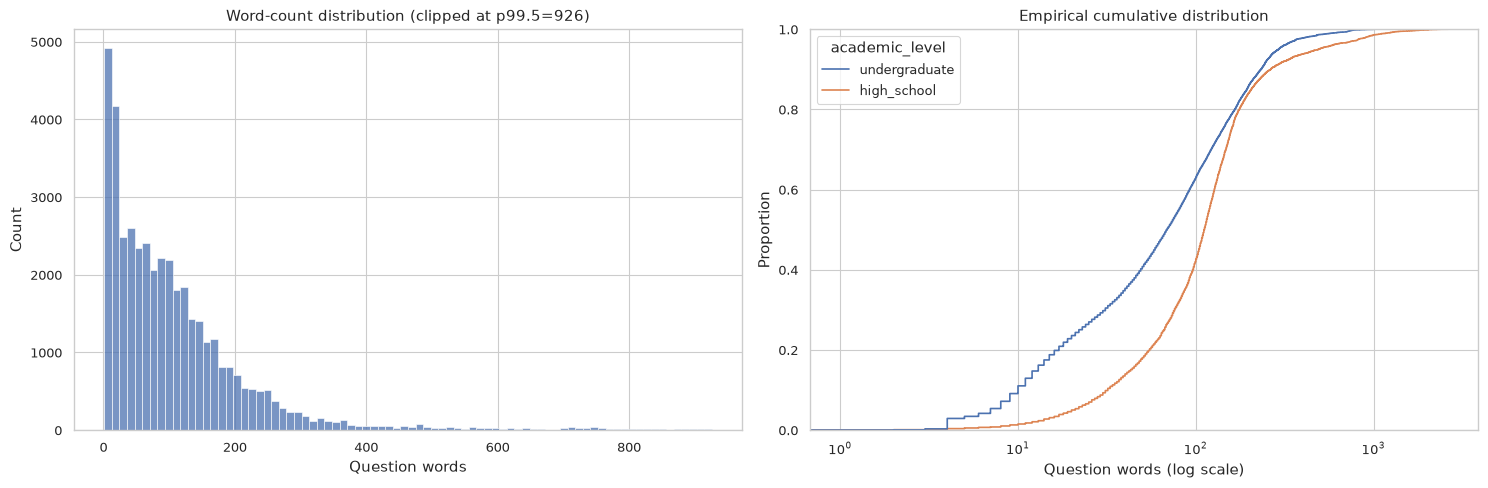

In [5]:
q995 = int(np.ceil(data["word_count"].quantile(0.995)))
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(data=data[data["word_count"] <= q995], x="word_count", bins=80, ax=axes[0])
axes[0].set(title=f"Word-count distribution (clipped at p99.5={q995})", xlabel="Question words")
sns.ecdfplot(data=data, x="word_count", hue="academic_level", ax=axes[1])
axes[1].set(xscale="log", title="Empirical cumulative distribution", xlabel="Question words (log scale)")
plt.tight_layout()
plt.show()

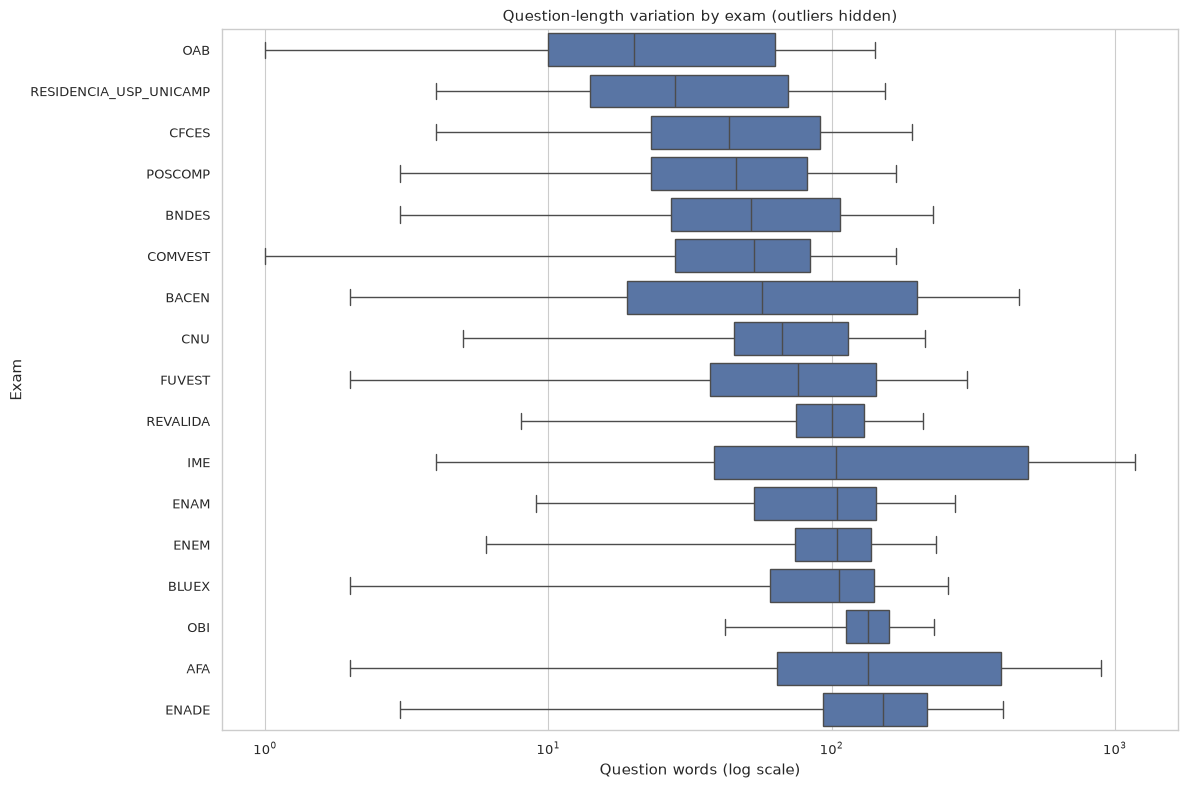

In [6]:
exam_order = exam_summary.sort_values("median").index
plt.figure(figsize=(12, 8))
sns.boxplot(
    data=data,
    y="exam",
    x="word_count",
    order=exam_order,
    showfliers=False,
    color="#4C72B0",
)
plt.xscale("log")
plt.title("Question-length variation by exam (outliers hidden)")
plt.xlabel("Question words (log scale)")
plt.ylabel("Exam")
plt.tight_layout()
plt.show()

## 3. Tail inspection

Length extremes are not automatically errors. The tables below retain identifying metadata and a normalized preview so that fragments and legitimate passage-based questions can be distinguished manually.

In [7]:
def preview_table(frame: pd.DataFrame, limit: int | None = None) -> pd.DataFrame:
    result = frame[["exam", "exam_edition", "num", "academic_level", "word_count", "question"]].copy()
    result["question"] = result["question"].str.replace(r"\s+", " ", regex=True).str.strip().str.slice(0, 240)
    return result.head(limit) if limit is not None else result

shortest = data.sort_values(["word_count", "exam", "exam_edition", "num"])
longest = data.sort_values(["word_count", "exam"], ascending=[False, True])
display(Markdown("### Twenty shortest questions"), preview_table(shortest, 20))
display(Markdown("### Twenty longest questions"), preview_table(longest, 20))

### Twenty shortest questions

,exam,exam_edition,num,academic_level,word_count,question
41019,COMVEST,COMVEST 2014,14,high_school,1,Assinale
41192,COMVEST,COMVEST 2016,49,high_school,1,Considere
38044,OAB,OAB-SP 2003.3,80,undergraduate,1,Imunidade:
16928,AFA,AFA_2016,33,high_school,2,The text
17103,AFA,AFA_2019,33,high_school,2,Cancer is
17107,AFA,AFA_2019,37,high_school,2,The text
548,BACEN,Analista de Finanças - Conhecimentos Específicos - 2006,22,undergraduate,2,A tentativa
772,BACEN,Analista de Sistemas - Conhecimentos Específicos - 2006,34,undergraduate,2,"No RUP,"
981,BACEN,Procurador - Conhecimentos Específicos - 2002,39,undergraduate,2,Preempção é:
41714,BLUEX,USP_2018,65,high_school,2,"Nesse texto,"


### Twenty longest questions

,exam,exam_edition,num,academic_level,word_count,question
40645,IME,IME 2021 - Portugues,20,high_school,2620,"ENGENHEIROS DA VITÓRIA Solução de problemas na história [...] Quando se fala na eficiência em conseguir equipamentos de combate e transferir combatentes de A para B, os britâni..."
40842,IME,IME 2024 - Portugues,20,high_school,2382,"Texto 1 O IMORTAL MEU PAI NASCEU em 1600... Perdão, em 1800, naturalmente... Não, senhor, replicou o dr. Leão, de um modo grave e triste; foi em 1600. Estupefação dos ouvintes,..."
40711,IME,IME 2022 - Portugues,15,high_school,2377,"Texto 1 Erico Verissimo (1905 – 1975), nascido em Cruz Alta (RS), foi um dos escritores mais populares da chamada segunda fase modernista, que começou na década de 1930. Sua ob..."
40712,IME,IME 2022 - Portugues,16,high_school,2348,"Texto 1 Erico Verissimo (1905 – 1975), nascido em Cruz Alta (RS), foi um dos escritores mais populares da chamada segunda fase modernista, que começou na década de 1930. Sua ob..."
40834,IME,IME 2024 - Portugues,12,high_school,2338,"Texto 1 O IMORTAL MEU PAI NASCEU em 1600... Perdão, em 1800, naturalmente... Não, senhor, replicou o dr. Leão, de um modo grave e triste; foi em 1600. Estupefação dos ouvintes,..."
40709,IME,IME 2022 - Portugues,13,high_school,2259,"Texto 1 Erico Verissimo (1905 – 1975), nascido em Cruz Alta (RS), foi um dos escritores mais populares da chamada segunda fase modernista, que começou na década de 1930. Sua ob..."
40710,IME,IME 2022 - Portugues,14,high_school,2259,"Texto 1 Erico Verissimo (1905 – 1975), nascido em Cruz Alta (RS), foi um dos escritores mais populares da chamada segunda fase modernista, que começou na década de 1930. Sua ob..."
40048,IME,IME 2012 - Portugues,10,high_school,2212,A IMPORTÂNCIA DO NÚMERO ZERO (Maria Fernanda Vomero – Abril de 2001) A invenção do zero foi uma das maiores aventuras intelectuais da humanidade – e não só para a matemática. A...
40045,IME,IME 2012 - Portugues,7,high_school,2209,A IMPORTÂNCIA DO NÚMERO ZERO (Maria Fernanda Vomero – Abril de 2001) A invenção do zero foi uma das maiores aventuras intelectuais da humanidade – e não só para a matemática. A...
40047,IME,IME 2012 - Portugues,9,high_school,2107,A IMPORTÂNCIA DO NÚMERO ZERO (Maria Fernanda Vomero – Abril de 2001) A invenção do zero foi uma das maiores aventuras intelectuais da humanidade – e não só para a matemática. A...


## 4. Threshold ablation

We report total retention, academic-level retention, the least-retained exam, and the maximum absolute change in exam prevalence. The latter measures representation shift in percentage points relative to the unfiltered population. Small exams should be interpreted together with their sample sizes.

In [8]:
baseline_exam_share = data["exam"].value_counts(normalize=True)
baseline_exam_size = data["exam"].value_counts()
baseline_level_size = data["academic_level"].value_counts()

def threshold_metrics(min_words: int, max_words: int) -> dict[str, float | int]:
    mask = data["word_count"].between(min_words, max_words, inclusive="both")
    retained = data.loc[mask]
    exam_retention = retained["exam"].value_counts().reindex(baseline_exam_size.index, fill_value=0) / baseline_exam_size
    retained_exam_share = retained["exam"].value_counts(normalize=True).reindex(baseline_exam_share.index, fill_value=0)
    level_retention = retained["academic_level"].value_counts().reindex(baseline_level_size.index, fill_value=0) / baseline_level_size
    return {
        "min_words": min_words,
        "max_words": max_words,
        "retained": int(mask.sum()),
        "removed": int((~mask).sum()),
        "retention_pct": 100 * mask.mean(),
        "high_school_retention_pct": 100 * level_retention.get("high_school", np.nan),
        "undergraduate_retention_pct": 100 * level_retention.get("undergraduate", np.nan),
        "worst_exam_retention_pct": 100 * exam_retention.min(),
        "worst_exam": str(exam_retention.idxmin()),
        "max_exam_share_shift_pp": 100 * (retained_exam_share - baseline_exam_share).abs().max(),
    }

minimum_ablation = pd.DataFrame(
    threshold_metrics(minimum, NEUTRAL_MAX) for minimum in MIN_THRESHOLDS
)
maximum_ablation = pd.DataFrame(
    threshold_metrics(NEUTRAL_MIN, maximum) for maximum in MAX_THRESHOLDS
)
display(Markdown("### Minimum-threshold ablation"), minimum_ablation)
display(Markdown("### Maximum-threshold ablation"), maximum_ablation)

### Minimum-threshold ablation

,min_words,max_words,retained,removed,retention_pct,high_school_retention_pct,undergraduate_retention_pct,worst_exam_retention_pct,worst_exam,max_exam_share_shift_pp
0,0,1000000,41987,0,100.000,100.000,100.000,100.000,ENADE,0.000
1,1,1000000,41987,0,100.000,100.000,100.000,100.000,ENADE,0.000
2,2,1000000,41984,3,99.993,99.980,99.997,99.566,COMVEST,0.005
3,3,1000000,41967,20,99.952,99.920,99.962,99.349,COMVEST,0.012
4,4,1000000,41882,105,99.750,99.850,99.719,98.698,COMVEST,0.113
5,5,1000000,41029,958,97.718,99.650,97.115,91.859,OAB,1.475
6,8,1000000,40195,1792,95.732,99.239,94.637,85.906,OAB,2.525
7,10,1000000,38951,3036,92.769,98.729,90.908,76.817,OAB,4.231
8,15,1000000,36120,5867,86.027,97.258,82.519,59.471,OAB,7.595
9,20,1000000,34242,7745,81.554,95.426,77.221,50.692,OAB,9.311


### Maximum-threshold ablation

,min_words,max_words,retained,removed,retention_pct,high_school_retention_pct,undergraduate_retention_pct,worst_exam_retention_pct,worst_exam,max_exam_share_shift_pp
0,0,100,24448,17539,58.228,42.644,63.094,12.299,OBI,13.447
1,0,200,36013,5974,85.772,84.327,86.223,57.532,IME,4.685
2,0,300,39694,2293,94.539,91.543,95.474,63.702,IME,1.414
3,0,500,41070,917,97.816,95.126,98.656,75.227,IME,0.606
4,0,750,41578,409,99.026,96.998,99.659,82.305,IME,0.443
5,0,1000,41835,152,99.638,98.569,99.972,88.022,IME,0.306
6,0,1500,41938,49,99.883,99.510,100.000,95.554,IME,0.114
7,0,2000,41967,20,99.952,99.800,100.000,98.185,IME,0.046
8,0,3000,41987,0,100.000,100.000,100.000,100.000,ENADE,0.000
9,0,1000000,41987,0,100.000,100.000,100.000,100.000,ENADE,0.000


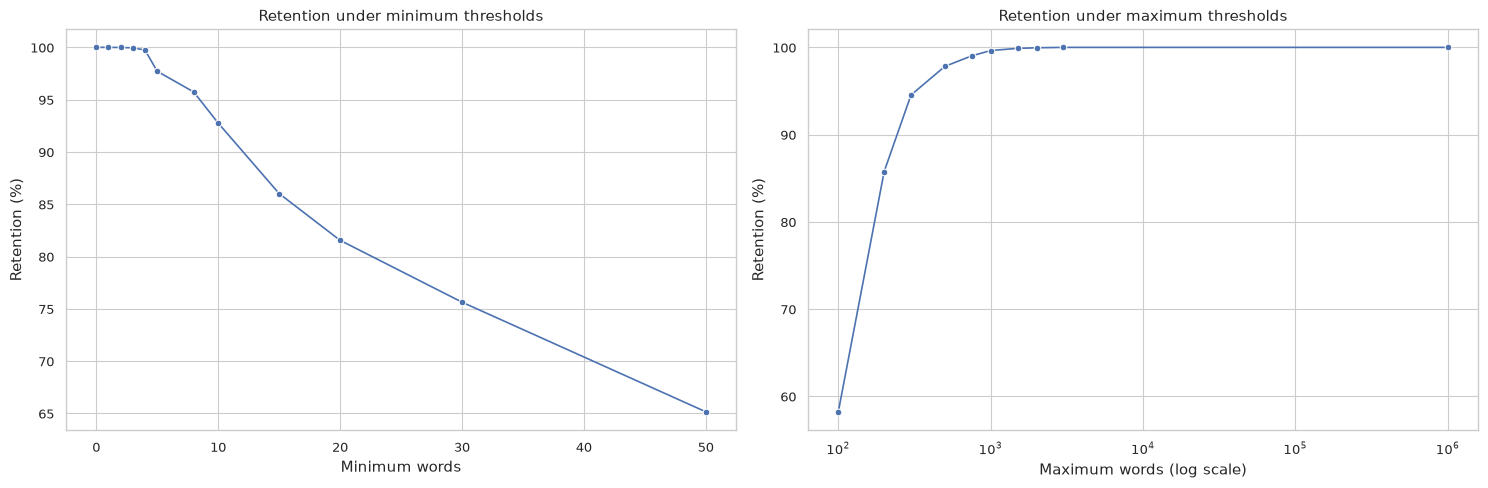

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.lineplot(data=minimum_ablation, x="min_words", y="retention_pct", marker="o", ax=axes[0])
axes[0].set(title="Retention under minimum thresholds", xlabel="Minimum words", ylabel="Retention (%)")
sns.lineplot(data=maximum_ablation, x="max_words", y="retention_pct", marker="o", ax=axes[1])
axes[1].set(xscale="log", title="Retention under maximum thresholds", xlabel="Maximum words (log scale)", ylabel="Retention (%)")
plt.tight_layout()
plt.show()

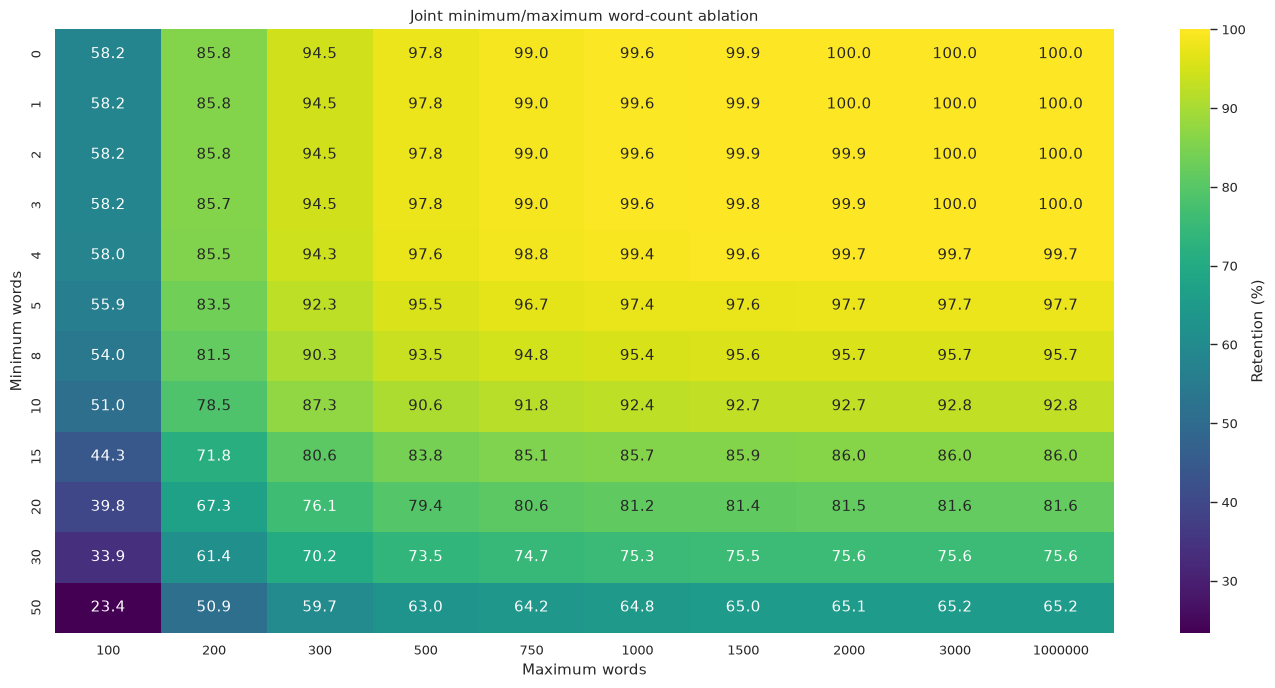

In [10]:
joint_rows = [
    threshold_metrics(minimum, maximum)
    for minimum in MIN_THRESHOLDS
    for maximum in MAX_THRESHOLDS
    if minimum <= maximum
]
joint_ablation = pd.DataFrame(joint_rows)
retention_grid = joint_ablation.pivot(index="min_words", columns="max_words", values="retention_pct")

plt.figure(figsize=(14, 7))
sns.heatmap(retention_grid, annot=True, fmt=".1f", cmap="viridis", cbar_kws={"label": "Retention (%)"})
plt.title("Joint minimum/maximum word-count ablation")
plt.xlabel("Maximum words")
plt.ylabel("Minimum words")
plt.tight_layout()
plt.show()

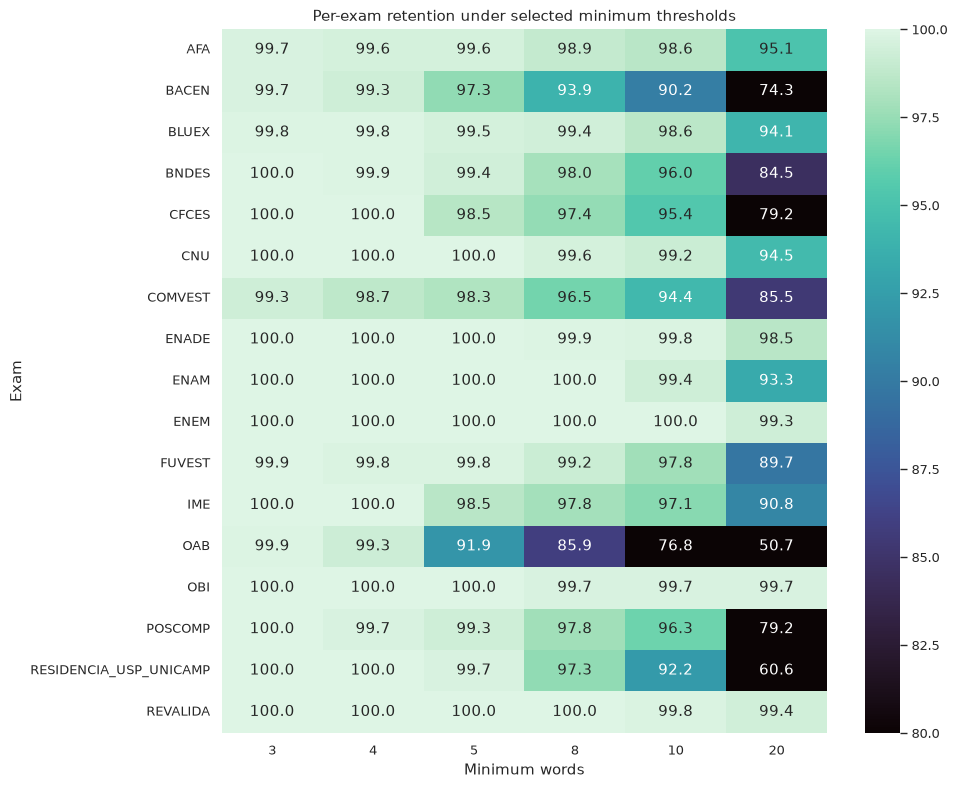

In [11]:
selected_minima = [3, 4, 5, 8, 10, 20]
exam_min_retention = pd.DataFrame(
    {
        minimum: (
            data.loc[data["word_count"] >= minimum, "exam"].value_counts().reindex(baseline_exam_size.index, fill_value=0)
            / baseline_exam_size
            * 100
        )
        for minimum in selected_minima
    }
).sort_index()

plt.figure(figsize=(10, 8))
sns.heatmap(exam_min_retention, annot=True, fmt=".1f", cmap="mako", vmin=80, vmax=100)
plt.title("Per-exam retention under selected minimum thresholds")
plt.xlabel("Minimum words")
plt.ylabel("Exam")
plt.tight_layout()
plt.show()

## 5. Deterministic boundary audit

The following samples support qualitative review. They are deterministic and stratified by length bands. They should be used to assess whether removals are malformed fragments, valid concise prompts, or valid long contexts.

In [12]:
def deterministic_sample(frame: pd.DataFrame, n: int = 8) -> pd.DataFrame:
    if frame.empty:
        return preview_table(frame)
    return preview_table(frame.sample(n=min(n, len(frame)), random_state=SEED).sort_values(["word_count", "exam"]))

short_bands = {
    "1-2 words": data[data["word_count"].between(1, 2)],
    "3 words": data[data["word_count"] == 3],
    "4 words": data[data["word_count"] == 4],
    "5 words": data[data["word_count"] == 5],
}
for label, frame in short_bands.items():
    display(Markdown(f"### {label}: {len(frame):,} records"), deterministic_sample(frame))

long_bands = {
    "501-1,000 words": data[data["word_count"].between(501, 1_000)],
    "1,001-2,000 words": data[data["word_count"].between(1_001, 2_000)],
    "More than 2,000 words": data[data["word_count"] > 2_000],
}
for label, frame in long_bands.items():
    display(Markdown(f"### {label}: {len(frame):,} records"), deterministic_sample(frame))

### 1-2 words: 20 records

,exam,exam_edition,num,academic_level,word_count,question
41192,COMVEST,COMVEST 2016,49,high_school,1,Considere
17103,AFA,AFA_2019,33,high_school,2,Cancer is
548,BACEN,Analista de Finanças - Conhecimentos Específicos - 2006,22,undergraduate,2,A tentativa
772,BACEN,Analista de Sistemas - Conhecimentos Específicos - 2006,34,undergraduate,2,"No RUP,"
3171,FUVEST,Fuvest 2002 - Segundo Dia,21,high_school,2,Os vírus
38535,OAB,OAB-MG 2001.3,30,undergraduate,2,Considera-se empregador::
34073,OAB,OAB-RJ 2007.1,69,undergraduate,2,A desapropriação
37271,OAB,OAB-SP 2004.3,82,undergraduate,2,As taxas


### 3 words: 85 records

,exam,exam_edition,num,academic_level,word_count,question
549,BACEN,Analista de Finanças - Conhecimentos Específicos - 2006,23,undergraduate,3,O arrependimento posterior
5566,BNDES,BNDES 2002 - Advogado,38,undergraduate,3,"Na arbitragem internacional,"
41077,COMVEST,COMVEST 2015,24,high_school,3,"No plano cartesiano,"
37832,OAB,OAB-DF 2004.1,28,undergraduate,3,Marque a incorreta
37820,OAB,OAB-DF 2004.1,16,undergraduate,3,Marque a incorreta
32501,OAB,OAB-MG 2008.3,63,undergraduate,3,O empresário individual:
31705,OAB,OAB-BR 2010.1,45,undergraduate,3,A ação rescisória
9561,POSCOMP,POSCOMP_2008,25,undergraduate,3,# Questão 25


### 4 words: 853 records

...

,exam,exam_edition,num,academic_level,word_count,question
6309,BNDES,BNDES 2008 - Administração,26,undergraduate,595,"Green is the hot topic these days, and the concept is having an impact on the way people think about datacenters. Companies around the world are announcing ways to save energy ..."
7447,BNDES,BNDES 2010 - Profissional Básico Análise de Sistemas e Suporte,22,undergraduate,612,Internacional Obama expondrá en el G-20 su reforma financie-ra como «modelo» a seguir Obama culpa a los bancos de desatar la peor crisis financiera en 80 años El País - ESPAÑA ...
25447,ENADE,ENADE 2018 - teologia,14,undergraduate,657,"TEXTO 1 A criação dos seres vivos e dos seres humanos (**Enuma Elish**, **Tábua VI**, linhas 5-8; 20-26) Sangue formarei, e farei com que haja osso; Então estabelecerei lullu, ..."
6904,BNDES,BNDES 2008 - Administração,28,undergraduate,669,"What are the best jobs of 2008? If you're job hunting in the professional or service-oriented fields, we have good news. Of the ten categories into which the Bureau of Labor St..."
8529,BNDES,BNDES 2013 - Administração,26,undergraduate,728,"Coworking: Sharing How We Work Genevieve DeGuzman Communication In the past, when trying to find places to work, independent workers, small businesses, and organizations often ..."
40796,IME,IME 2023 - Portugues,39,high_school,739,"Text 3: Climate of conspiracy: A meta-analysis of the consequences of belief in conspiracy theories about climate change By Mikey Biddlestone, Flavio Azevedo, Sander van der Li..."
8013,BNDES,BNDES 2011 - Engenheiro,30,undergraduate,782,"Why Companies Need Less Innovation By Pat Lencioni Perhaps the most popular and misunderstood- term of the first decade of the new millennium is ""innovation."" A new stack of bo..."
17235,AFA,AFA_2021,47,high_school,791,"TEXTO: TEXTO II A VERDADEIRA LEI DE GÉRSON Raul Marinho Gregorin Você se lembra daquele célebre comercial do cigarro Vila Rica, onde nosso tricampeão Gérson falava a famosa fra..."


### 1,001-2,000 words: 132 records

,exam,exam_edition,num,academic_level,word_count,question
40182,IME,IME 2014 - Portugues,16,high_school,1092,Text 1 Luis Suárez joins anti-racism calls after Dani Alves banana incident The Barcelona defender Dani Alves has sparked a social media campaign against racism in football as ...
40734,IME,IME 2022 - Portugues,38,high_school,1205,"Text 2 Overview of current additive manufacturing technologies and selected applications Horn, T..J. e Harrysson, O.L Three-dimensional printing or rapid prototyping are proces..."
40494,IME,IME 2019 - Portugues,3,high_school,1261,"A primeira publicação do conto O Alienista, de Machado de Assis, ocorreu como folhetim na revista carioca A Estação, entre os anos de 1881 e 1882. Nessa mesma época, uma grande..."
17391,AFA,AFA_2024,14,high_school,1407,"TEXTO: TEXTO I Black Mirror: ""Queda livre"", a desumanização do futuro Queda Livre, o enredo ""Queda Livre"" nos lembra da invasão das redes sociais que vivemos hoje e nos leva a ..."
40637,IME,IME 2021 - Portugues,12,high_school,1474,"ENGENHEIROS DA VITÓRIA Solução de problemas na história [...] Quando se fala na eficiência em conseguir equipamentos de combate e transferir combatentes de A para B, os britâni..."
40493,IME,IME 2019 - Portugues,2,high_school,1477,"A primeira publicação do conto O Alienista, de Machado de Assis, ocorreu como folhetim na revista carioca A Estação, entre os anos de 1881 e 1882. Nessa mesma época, uma grande..."
40829,IME,IME 2024 - Portugues,7,high_school,1643,"Texto 1 O IMORTAL MEU PAI NASCEU em 1600... Perdão, em 1800, naturalmente... Não, senhor, replicou o dr. Leão, de um modo grave e triste; foi em 1600. Estupefação dos ouvintes,..."
40573,IME,IME 2020 - Portugues,14,high_school,1792,"Texto 1 CAPÍTULO 3 A GUERRA DAS CAATINGAS Os doutores na arte de matar que hoje, na Europa, invadem escandalosamente a ciência, perturbando-lhe o remanso com um retinir de espo..."


### More than 2,000 words: 20 records

,exam,exam_edition,num,academic_level,word_count,question
40044,IME,IME 2012 - Portugues,6,high_school,2007,A IMPORTÂNCIA DO NÚMERO ZERO (Maria Fernanda Vomero – Abril de 2001) A invenção do zero foi uma das maiores aventuras intelectuais da humanidade – e não só para a matemática. A...
40052,IME,IME 2012 - Portugues,14,high_school,2028,A IMPORTÂNCIA DO NÚMERO ZERO (Maria Fernanda Vomero – Abril de 2001) A invenção do zero foi uma das maiores aventuras intelectuais da humanidade – e não só para a matemática. A...
40042,IME,IME 2012 - Portugues,4,high_school,2037,A IMPORTÂNCIA DO NÚMERO ZERO (Maria Fernanda Vomero – Abril de 2001) A invenção do zero foi uma das maiores aventuras intelectuais da humanidade – e não só para a matemática. A...
40040,IME,IME 2012 - Portugues,2,high_school,2044,A IMPORTÂNCIA DO NÚMERO ZERO (Maria Fernanda Vomero – Abril de 2001) A invenção do zero foi uma das maiores aventuras intelectuais da humanidade – e não só para a matemática. A...
40039,IME,IME 2012 - Portugues,1,high_school,2051,A IMPORTÂNCIA DO NÚMERO ZERO (Maria Fernanda Vomero – Abril de 2001) A invenção do zero foi uma das maiores aventuras intelectuais da humanidade – e não só para a matemática. A...
40048,IME,IME 2012 - Portugues,10,high_school,2212,A IMPORTÂNCIA DO NÚMERO ZERO (Maria Fernanda Vomero – Abril de 2001) A invenção do zero foi uma das maiores aventuras intelectuais da humanidade – e não só para a matemática. A...
40710,IME,IME 2022 - Portugues,14,high_school,2259,"Texto 1 Erico Verissimo (1905 – 1975), nascido em Cruz Alta (RS), foi um dos escritores mais populares da chamada segunda fase modernista, que começou na década de 1930. Sua ob..."
40712,IME,IME 2022 - Portugues,16,high_school,2348,"Texto 1 Erico Verissimo (1905 – 1975), nascido em Cruz Alta (RS), foi um dos escritores mais populares da chamada segunda fase modernista, que começou na década de 1930. Sua ob..."


In [13]:
candidate_pairs = [
    (0, 1_000_000),
    (1, 1_000_000),
    (2, 1_000_000),
    (3, 1_000_000),
    (4, 1_000_000),
    (5, 1_000_000),
    (4, 2_000),
    (4, 1_000),
    (4, 500),
]
candidate_comparison = pd.DataFrame(
    threshold_metrics(minimum, maximum) for minimum, maximum in candidate_pairs
)
display(Markdown("## 6. Candidate configurations"), candidate_comparison)

## 6. Candidate configurations

,min_words,max_words,retained,removed,retention_pct,high_school_retention_pct,undergraduate_retention_pct,worst_exam_retention_pct,worst_exam,max_exam_share_shift_pp
0,0,1000000,41987,0,100.000,100.000,100.000,100.000,ENADE,0.000
1,1,1000000,41987,0,100.000,100.000,100.000,100.000,ENADE,0.000
2,2,1000000,41984,3,99.993,99.980,99.997,99.566,COMVEST,0.005
3,3,1000000,41967,20,99.952,99.920,99.962,99.349,COMVEST,0.012
4,4,1000000,41882,105,99.750,99.850,99.719,98.698,COMVEST,0.113
5,5,1000000,41029,958,97.718,99.650,97.115,91.859,OAB,1.475
6,4,2000,41862,125,99.702,99.650,99.719,98.185,IME,0.101
7,4,1000,41730,257,99.388,98.419,99.691,88.022,IME,0.300
8,4,500,40965,1022,97.566,94.976,98.375,75.227,IME,0.601


In [14]:
short_counts = data["word_count"].value_counts().sort_index()
long_count_1000 = int((data["word_count"] > 1_000).sum())
long_count_2000 = int((data["word_count"] > 2_000).sum())
display(
    Markdown(
        f"""## Evidence summary

- Baseline population: **{len(data):,}** structurally valid questions.
- Questions with at most 2 words: **{int((data['word_count'] <= 2).sum()):,}**.
- Questions with at most 3 words: **{int((data['word_count'] <= 3).sum()):,}**.
- Questions longer than 1,000 words: **{long_count_1000:,}**.
- Questions longer than 2,000 words: **{long_count_2000:,}**.

Threshold selection must combine these coverage results with the boundary audit above."""
    )
)

## Evidence summary

- Baseline population: **41,987** structurally valid questions.
- Questions with at most 2 words: **20**.
- Questions with at most 3 words: **105**.
- Questions longer than 1,000 words: **152**.
- Questions longer than 2,000 words: **20**.

Threshold selection must combine these coverage results with the boundary audit above.

## 7. Threats to validity

1. **No semantic labels.** Retention is not equivalent to quality; the audit can reveal obvious fragments but does not estimate annotation error rates.
2. **No downstream evaluation.** This study does not measure effects on model accuracy, calibration, or robustness.
3. **Whitespace-based words.** The Curator metric is intentionally reproduced, but it is not a model tokenizer and does not predict context-window usage exactly.
4. **Source imbalance.** Large exams dominate aggregate statistics; subgroup results must accompany global retention.
5. **Passage-based questions.** Long shared source texts may be repeated across several questions and should not be treated as malformed solely because they are outliers.

The final configuration should therefore choose a lower bound supported by fragment inspection and treat any upper bound as an operational coverage decision rather than a semantic-quality guarantee.

## 8. Conclusion and selected operating point

Based on the quantitative ablation and the manual boundary inspection, the selected configuration is **`min_words=4` and `max_words=1_000`**. Both endpoints are inclusive under NeMo Curator's `WordCountFilter`.

The lower threshold excludes the 105 records containing only one to three words. Manual inspection showed that this extreme lower tail has the greatest concentration of prompts that appear truncated, underspecified, or compatible with OCR and extraction failures. In contrast, the four-word boundary contains concise but structurally complete MCQA formulations, such as imperative prompts asking the reader to select the correct or incorrect alternative. Some shorter stems can still be completed by their answer choices, so this threshold deliberately favors structural reliability over retaining every terse formulation; it should not be interpreted as proof that every removed item is semantically invalid.

The upper threshold is supported by the empirical distribution: the 99th percentile is 746 words and the 99.5th percentile is approximately 925 words. A 1,000-word ceiling therefore lies above more than 99.5% of the corpus while excluding the most extreme length tail. Applied alone, it removes 152 records (0.362%). The long-tail audit shows that several excluded items contain genuine passage-based material, especially from IME, so this cutoff is justified as an operational decision to control unusually large examples, repeated source passages, and processing cost—not as evidence that texts above 1,000 words are intrinsically low quality.

Together, the selected thresholds retain **41,730 of 41,987 records (99.388%)** and remove **257 records (0.612%)**. Retention is 98.419% for high-school questions and 99.691% for undergraduate questions. The largest source-specific effect occurs for IME, which retains 970 of 1,102 records (88.022%); this expected asymmetry follows from its unusually long passage-based questions and should be monitored in downstream experiments.

The selected operating point is therefore:

```python
WordCountFilter(min_words=4, max_words=1_000, lang="pt")
```

This conclusion is supported by corpus coverage and manual structural inspection. It remains a filtering policy rather than a semantic-quality result: downstream evaluation or formal human annotation would be required to determine whether the removed tail improves benchmark validity or model performance.